In [14]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [15]:
# Load the Iris dataset

iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target/species column
df["species"] = iris.target

# Display first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [16]:
# Check the dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [17]:
# Check basic statistical information

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [18]:
# Check the number of samples in each species

df["species"].value_counts()

,count
species,
0,50
1,50
2,50


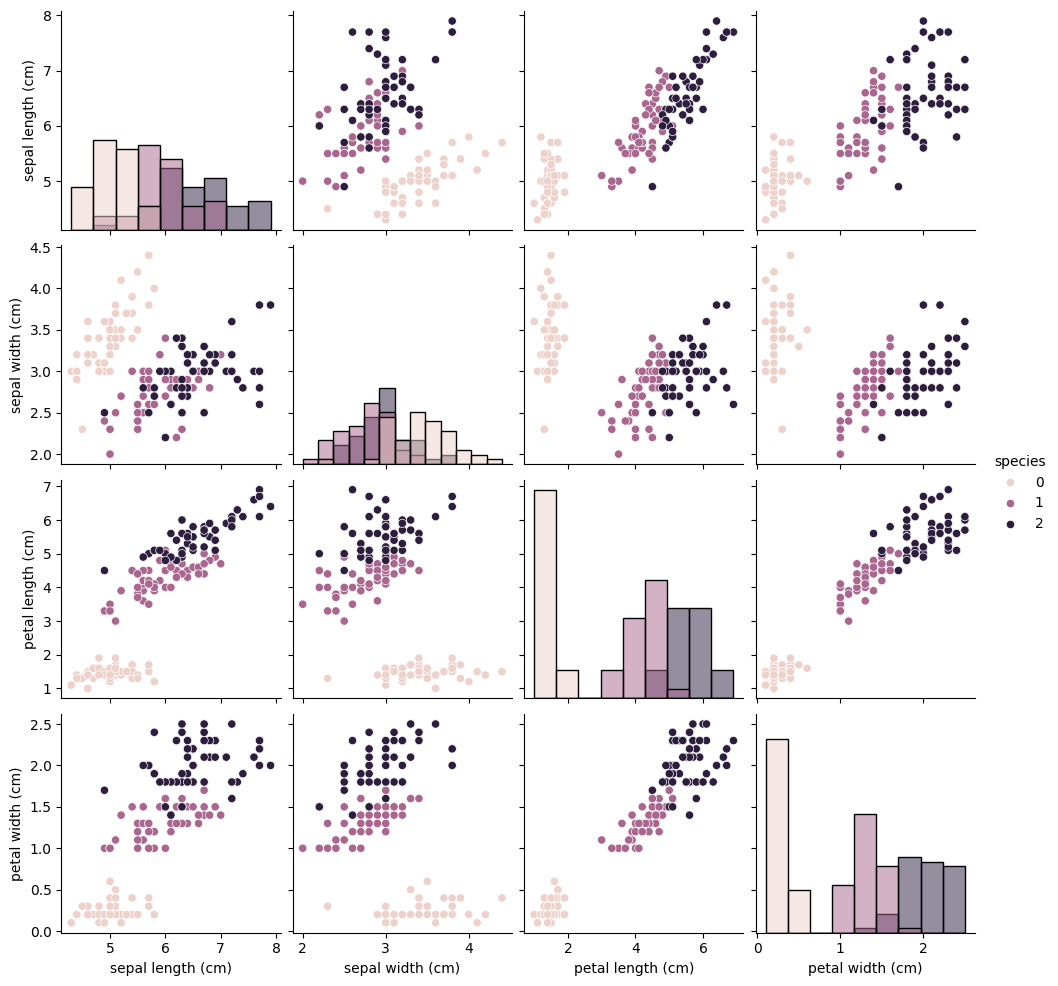

In [19]:
# Visualize relationships between features

sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.show()

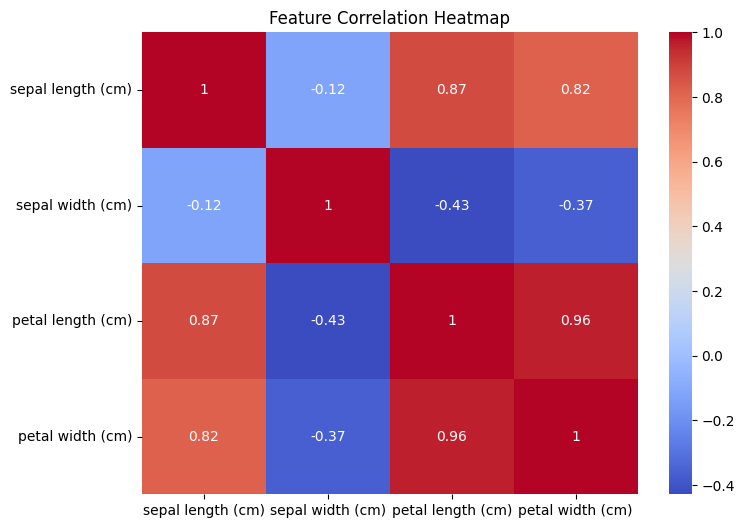

In [20]:
# Correlation between numerical features

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.drop(columns=["species"]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

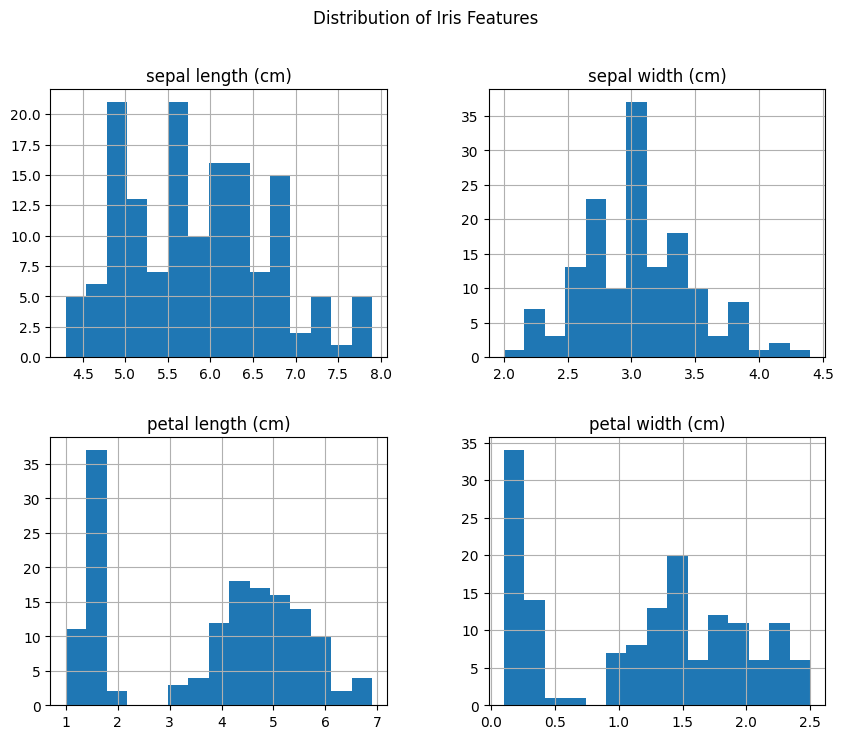

In [21]:
# Distribution of Iris flower measurements

df.drop(columns=["species"]).hist(
    figsize=(10, 8),
    bins=15
)

plt.suptitle("Distribution of Iris Features")
plt.show()

In [22]:
# Separate features and target

X = df.drop(columns=["species"])
y = df["species"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int64


In [23]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [24]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


In [26]:
# Train Logistic Regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 96.67 %


In [27]:
# Train K-Nearest Neighbors model

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("K-Nearest Neighbors Accuracy:",
      round(knn_accuracy * 100, 2), "%")

K-Nearest Neighbors Accuracy: 100.0 %


In [28]:
# Train Decision Tree model

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = decision_tree_model.predict(X_test)

# Calculate accuracy
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:",
      round(tree_accuracy * 100, 2), "%")

Decision Tree Accuracy: 93.33 %


In [29]:
# Compare model accuracies

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Decision Tree"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        tree_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.966667,96.666667
1,K-Nearest Neighbors,1.000000,100.000000
2,Decision Tree,0.933333,93.333333


In [30]:
from sklearn.metrics import classification_report

# Classification report for KNN

print("Classification Report - K-Nearest Neighbors")
print()

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

Classification Report - K-Nearest Neighbors

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



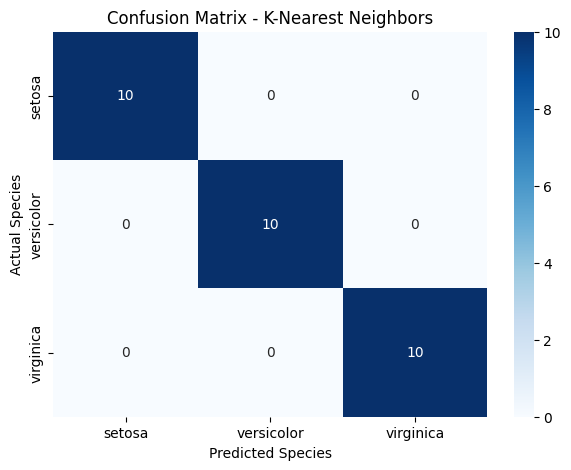

In [31]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("Confusion Matrix - K-Nearest Neighbors")

plt.show()

In [34]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns
)

prediction = knn_model.predict(new_flower)

predicted_species = iris.target_names[prediction[0]]

print("Predicted Iris Species:", predicted_species)

Predicted Iris Species: setosa


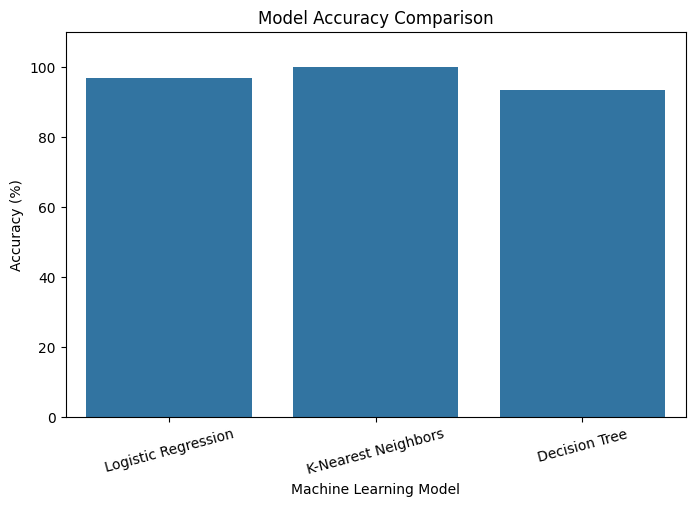

In [35]:
# Compare model accuracies visually

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="Accuracy (%)",
    data=results
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Machine Learning Model")
plt.ylim(0, 110)

plt.xticks(rotation=15)
plt.show()